In [1]:
import os

os.chdir("..")
os.getcwd()

'/home/borealis/Documents/work/projects/work_tests/SpeakVer'

In [2]:
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

from src.data.audio_preprocessor import AudioPreprocessor
from src.train.dynamic_batch_sampler import DynamicBatchSampler
from src.train.speaker_dataset import SpeakerDataset
from src.utils.utils import collate_fn

In [3]:
MAX_BATCH_SIZE = 64
MIN_BATCH_SIZE = 4
TARGET_SR = 8000

# Paths
TRAIN_PATH = "speaker_dataset_new/train"
VAL_PATH = "speaker_dataset_new/val"
TEST_PATH = "speaker_dataset_new/test"
LENGTHS_CACHE_PATH = "speaker_dataset_new/lengths_cache.pkl"

MIC_TYPE = "throat_microphone"

In [4]:
train_preprocessor = AudioPreprocessor(
    resample=True,
    augment=True,
    fix_length=False,
    target_sr=TARGET_SR,
)
val_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
)
test_preprocessor = AudioPreprocessor(
    resample=True,
    augment=False,
    fix_length=False,
    target_sr=TARGET_SR,
)

In [5]:
train_dataset = SpeakerDataset(
    TRAIN_PATH,
    preprocessor=train_preprocessor,
    return_audio=True,
    microphone=MIC_TYPE,
)
val_dataset = SpeakerDataset(
    VAL_PATH,
    preprocessor=val_preprocessor,
    return_audio=False,
    microphone=MIC_TYPE,
)
test_dataset = SpeakerDataset(
    TEST_PATH,
    preprocessor=test_preprocessor,
    return_audio=False,
    microphone=MIC_TYPE,
)

In [6]:
train_dataset_stats = train_dataset.statistics()
val_dataset_stats = val_dataset.statistics()
test_dataset_stats = test_dataset.statistics()

In [7]:
if not os.path.exists(LENGTHS_CACHE_PATH):
    lengths = [
        item["length"] for item in tqdm(train_dataset, total=len(train_dataset))
    ]

    with open(LENGTHS_CACHE_PATH, "wb") as file:
        pickle.dump(lengths, file)
else:
    with open(LENGTHS_CACHE_PATH, "rb") as file:
        lengths = pickle.load(file)

In [8]:
MAX_BATCH_LENGTH = int(
    np.quantile(
        train_dataset_stats["durations_distribution"], 0.9
    ) * MAX_BATCH_SIZE * TARGET_SR
)
batch_sampler = DynamicBatchSampler(
    lengths=lengths, 
    max_batch_length=MAX_BATCH_LENGTH, 
    bucket_size=512, 
    max_batch_size=MAX_BATCH_SIZE, 
    min_batch_size=MIN_BATCH_SIZE, 
    shuffle=True,
    seed=42
)

In [9]:
train_dataloader = DataLoader(
    train_dataset,
    collate_fn=collate_fn,
    batch_sampler=batch_sampler,
)

In [10]:
batch_lengths_path = "notebooks/batch_lengths.json"

if os.path.exists(batch_lengths_path):
    with open(batch_lengths_path, "rb") as file:
        batch_lengths = json.load(file)
else:
    batch_lengths = {}

    for i, batch in tqdm(
        enumerate(train_dataloader, 1), total=len(train_dataloader)
    ):
        batch_lengths[f"batch {i}"] = batch["lengths"].tolist()

    with open(batch_lengths_path, "w", encoding="utf-8") as f:
        json.dump(batch_lengths, f, indent=4, ensure_ascii=False)

In [11]:
batch_lengths_stats = {
    key: pd.Series(value).describe() for key, value in batch_lengths.items()
}

batch_lengths_stats

{'batch 1': count    64.000000
 mean      0.997229
 std       0.002308
 min       0.992832
 25%       0.995878
 50%       0.996774
 75%       1.000000
 max       1.000000
 dtype: float64,
 'batch 2': count    64.000000
 mean      0.995544
 std       0.002466
 min       0.992053
 25%       0.993378
 50%       0.995254
 75%       0.997792
 max       1.000000
 dtype: float64,
 'batch 3': count    64.000000
 mean      0.972892
 std       0.017328
 min       0.940064
 25%       0.959171
 50%       0.974256
 75%       0.986625
 max       1.000000
 dtype: float64,
 'batch 4': count    64.000000
 mean      0.995042
 std       0.002273
 min       0.991736
 25%       0.992872
 50%       0.995661
 75%       0.995868
 max       1.000000
 dtype: float64,
 'batch 5': count    64.000000
 mean      0.993772
 std       0.003710
 min       0.986885
 25%       0.990164
 50%       0.993443
 75%       0.996721
 max       1.000000
 dtype: float64,
 'batch 6': count    64.000000
 mean      0.994765
 std     

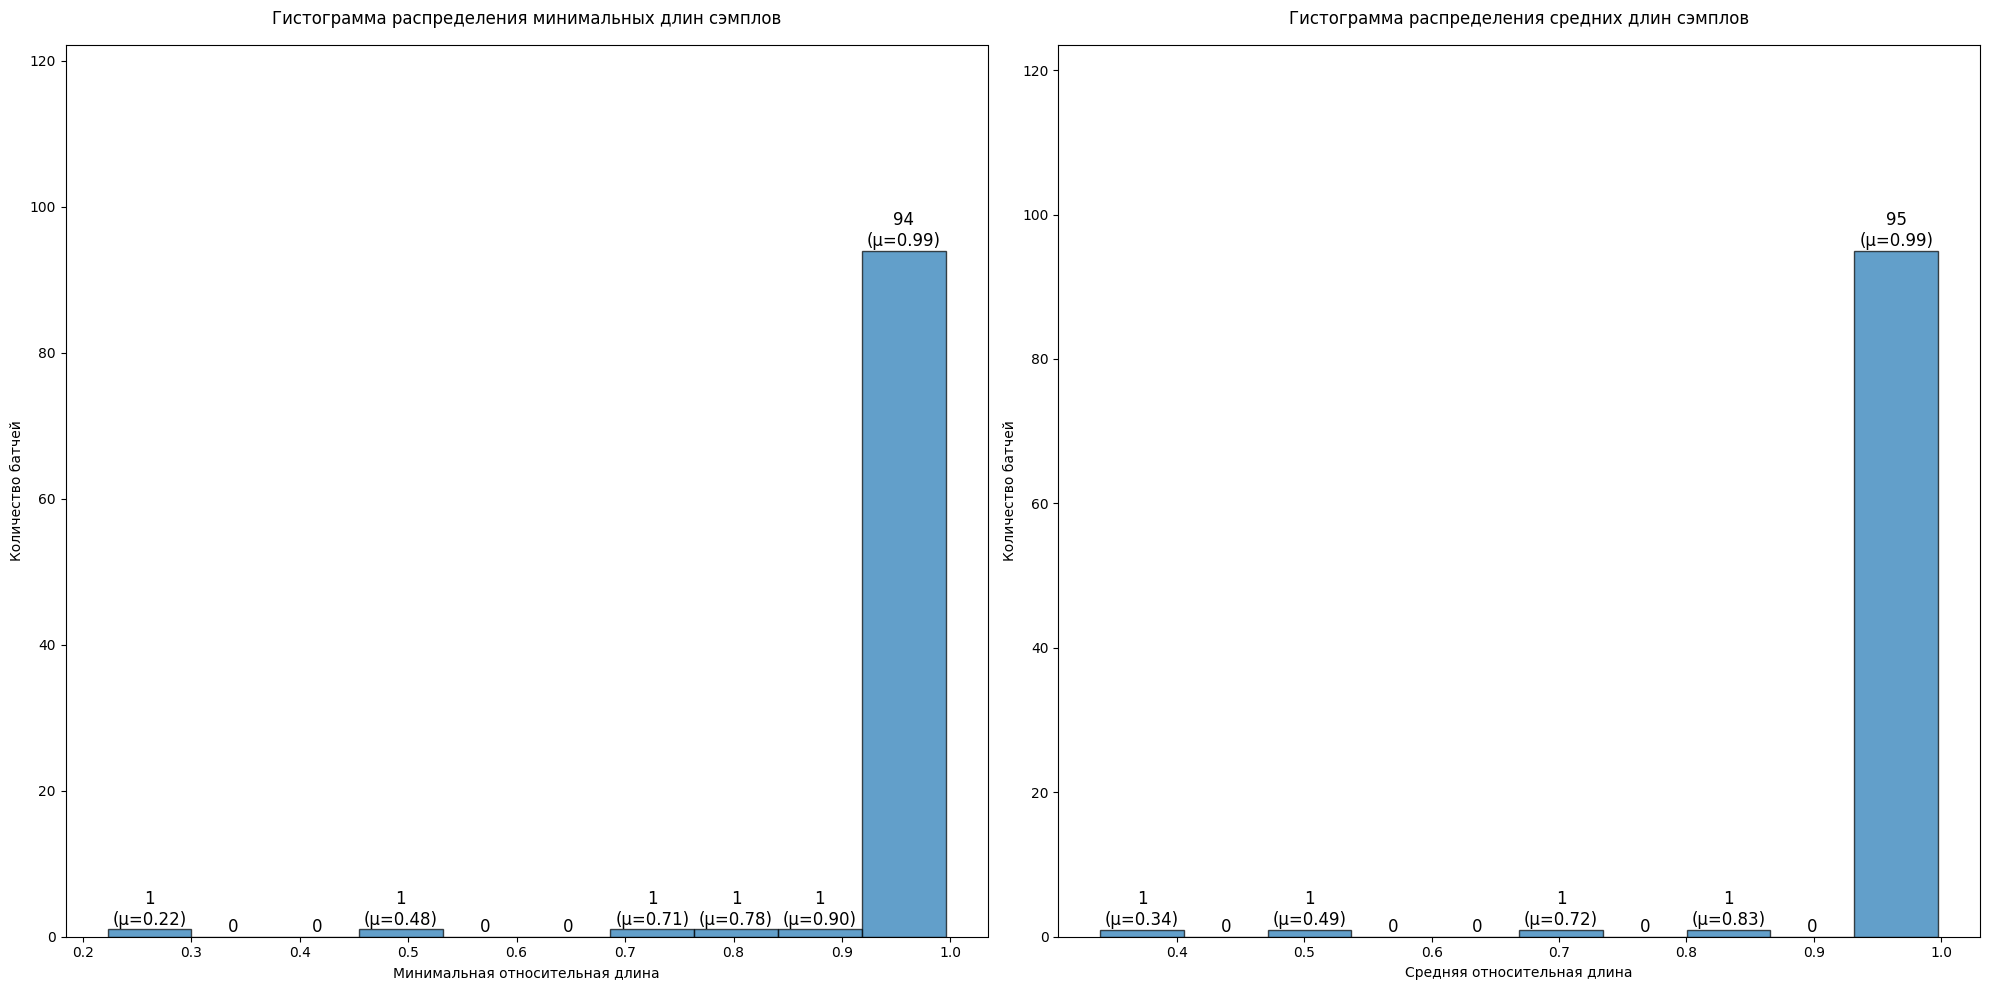

In [12]:
data_mean = np.array([float(value["mean"]) for value in batch_lengths_stats.values()])
data_min = np.array([float(value["min"]) for value in batch_lengths_stats.values()])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))


def draw_stat_hist(ax, data, title, xlabel):
    n, bins, patches = ax.hist(data, edgecolor="black", alpha=0.7)

    for i in range(len(patches)):
        if i == len(patches) - 1:
            mask = (data >= bins[i]) & (data <= bins[i + 1])
        else:
            mask = (data >= bins[i]) & (data < bins[i + 1])

        bin_data = data[mask]
        count = int(n[i])

        if count > 0:
            bin_mean = bin_data.mean()
            label_text = f"{count}\n(μ={bin_mean:.2f})"
        else:
            label_text = "0"

        x_pos = patches[i].get_x() + patches[i].get_width() / 2
        y_pos = patches[i].get_height()

        ax.text(
            x_pos, y_pos + 0.1, label_text, ha="center", va="bottom", fontsize=12
        )

    ax.set_title(title, fontsize=12, pad=15)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Количество батчей", fontsize=10)

    ax.set_ylim(0, max(n) * 1.3)


draw_stat_hist(
    axes[0],
    data_min,
    "Гистограмма распределения минимальных длин сэмплов",
    "Минимальная относительная длина",
)
draw_stat_hist(
    axes[1],
    data_mean,
    "Гистограмма распределения средних длин сэмплов",
    "Средняя относительная длина",
)

plt.tight_layout()

plt.show()


In [13]:
total_real = 0
total_padded = 0

for length in batch_lengths.values():
    max_len = max(length)

    total_real += sum(length)
    total_padded += len(length) * max_len

padding_ratio = 1 - total_real / total_padded

print(f"Padding ratio: {padding_ratio:.4%}")

Padding ratio: 2.2043%


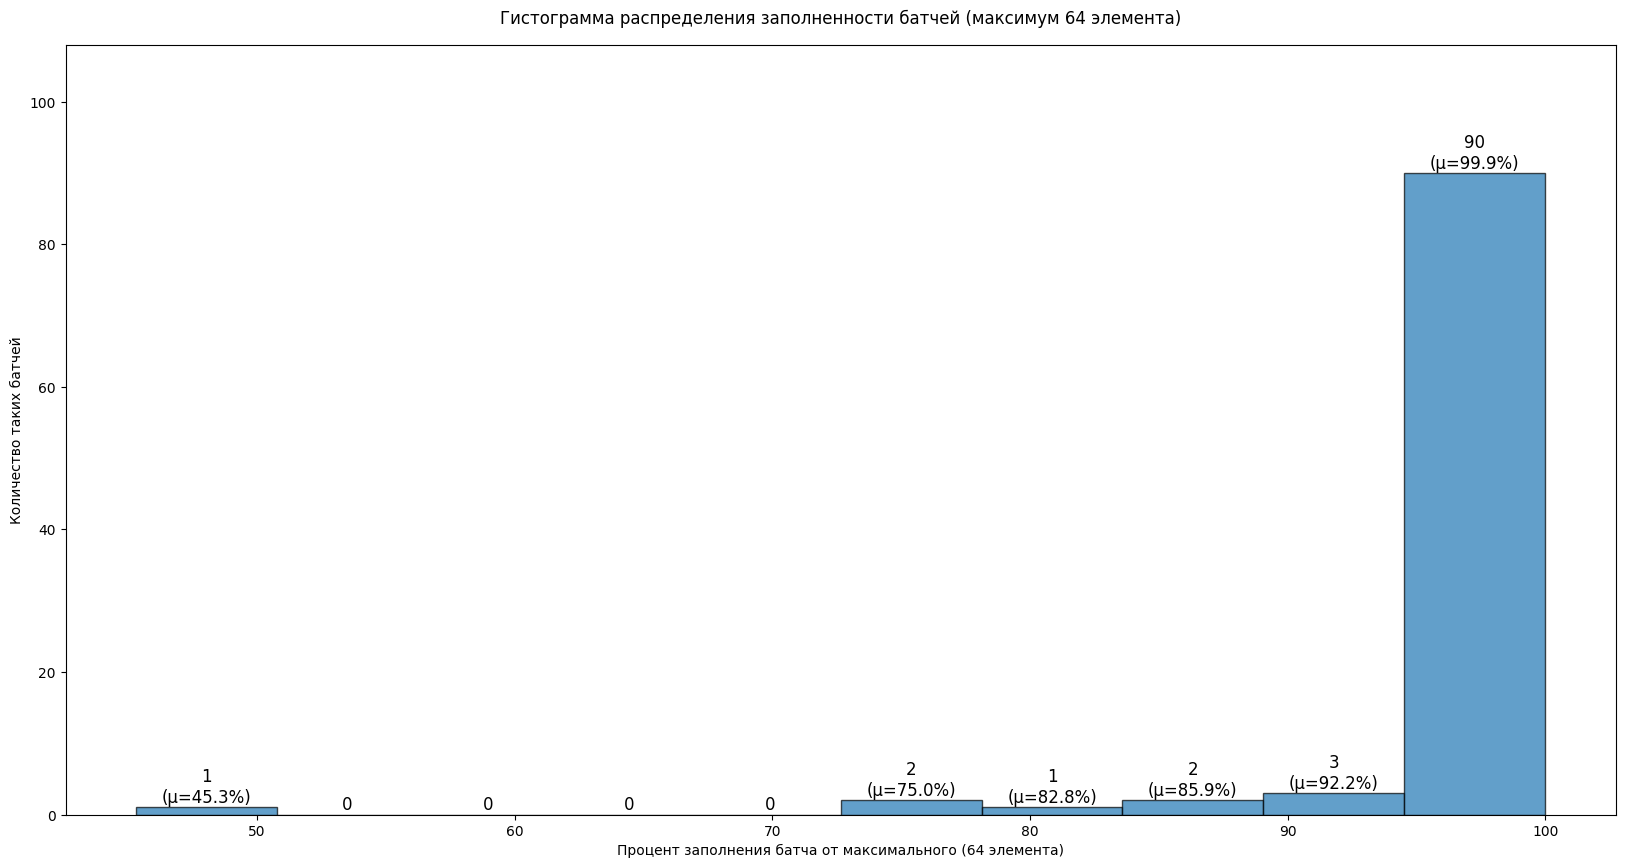

In [14]:
ratio_lengths_batch = []

for bl in batch_lengths.values():
    ratio_lengths_batch.append((len(bl) / 64) * 100)

data = np.array(ratio_lengths_batch)

plt.figure(figsize=(20, 10))

n, bins, patches = plt.hist(data, edgecolor="black", alpha=0.7)

for i in range(len(patches)):
    if i == len(patches) - 1:
        mask = (data >= bins[i]) & (data <= bins[i + 1])
    else:
        mask = (data >= bins[i]) & (data < bins[i + 1])

    bin_data = data[mask]
    count = int(n[i])

    if count > 0:
        bin_mean = bin_data.mean()
        label_text = (
            f"{count}\n(μ={bin_mean:.1f}%)" 
        )
    else:
        label_text = "0"

    x_pos = patches[i].get_x() + patches[i].get_width() / 2
    y_pos = patches[i].get_height()

    plt.text(x_pos, y_pos + 0.1, label_text, ha="center", va="bottom", fontsize=12)

plt.title(
    "Гистограмма распределения заполненности батчей (максимум 64 элемента)",
    fontsize=12,
    pad=15,
)
plt.xlabel(
    "Процент заполнения батча от максимального (64 элемента)", fontsize=10
)
plt.ylabel("Количество таких батчей", fontsize=10)

plt.ylim(0, max(n) * 1.2)

plt.show()